# Analisis 5W+1H - Chicago Crime (Part 3: WHEN)

Bagian ini berfokus pada **WHEN (Kapan)**, menganalisis waktu terjadinya kejahatan berdasarkan distribusi jam, hari dalam seminggu, bulan, musim, hingga perbandingan Siang vs Malam dan Hari Kerja vs Akhir Pekan.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Pastikan direktori output ada
OUT = r'c:\Python\Data_Mining\output_5w1h'
os.makedirs(OUT, exist_ok=True)

print("Setup selesai.")

Setup selesai.


In [12]:
# Load data (Fallback ke CSV jika pickle dari proses sebelumnya belum ada)
pickle_path = f'{OUT}/_temp_df.pkl'

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print(f"Data berhasil dimuat dari pickle: {len(df):,} baris.")
else:
    print("File pickle tidak ditemukan. Memuat dari Mining.csv dan melakukan preprocessing...")
    cols = ['Date','Primary Type','Description','Location Description',
            'Arrest','Domestic','District','Ward','Community Area',
            'Year','Latitude','Longitude','Beat','IUCR','FBI Code','Block']
    df = pd.read_csv(r'c:\Python\Data_Mining\Mining.csv', usecols=cols, nrows=500000, low_memory=False)
    df = df.sample(n=300000, random_state=42).reset_index(drop=True)

    # Feature Engineering yang diperlukan untuk seluruh analisis 5W1H
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month

    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',
                  9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)
    df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    severity_map = {'01A':'Kritis','01B':'Kritis',
        '02':'Tinggi','04A':'Tinggi','04B':'Tinggi','03':'Tinggi','15':'Tinggi',
        '05':'Sedang','06':'Sedang','07':'Sedang','09':'Sedang','08A':'Sedang','08B':'Sedang',
        '10':'Rendah','11':'Rendah','14':'Rendah','16':'Rendah','17':'Rendah',
        '18':'Rendah','19':'Rendah','20':'Rendah','22':'Rendah','24':'Rendah','26':'Rendah'}
    df['CrimeSeverity'] = df['FBI Code'].map(severity_map).fillna('Rendah')

    df.to_pickle(pickle_path)
    print(f"Pre-processing selesai. Data disimpan ke pickle. Sample: {len(df):,} rows.")

Data berhasil dimuat dari pickle: 300,000 baris.


---
## OPSI 3: WHEN - Kapan Kejahatan Terjadi?
---


[3.1] Distribusi Kejahatan per Jam:


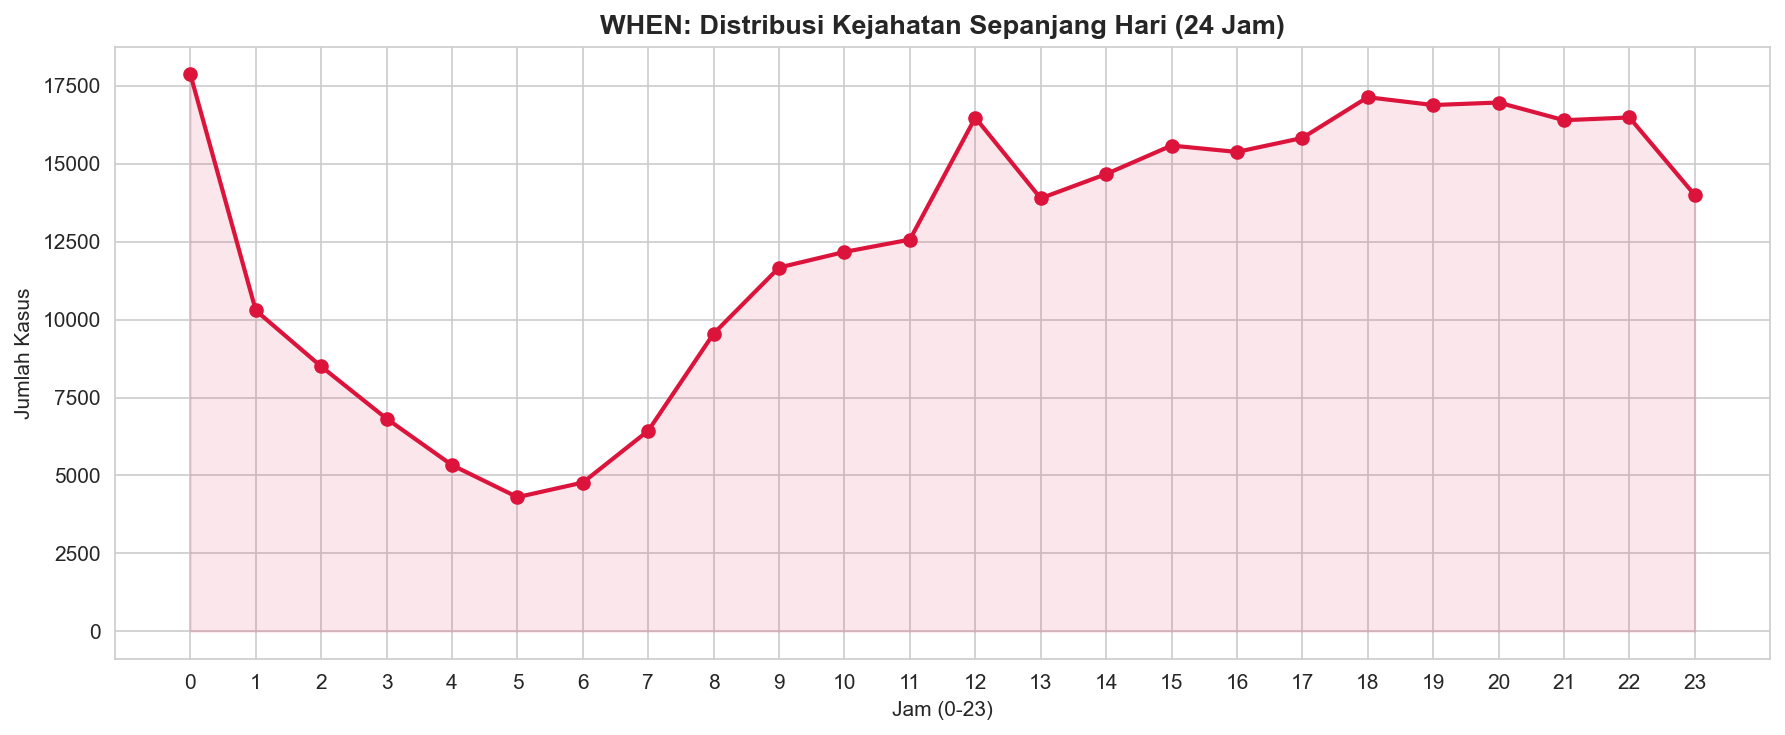

In [13]:
print("\n[3.1] Distribusi Kejahatan per Jam:")
hourly = df['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
hourly.plot(kind='line', marker='o', color='crimson', linewidth=2, ax=ax)
ax.fill_between(hourly.index, hourly.values, color='crimson', alpha=0.1)
ax.set_title('WHEN: Distribusi Kejahatan Sepanjang Hari (24 Jam)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam (0-23)')
ax.set_ylabel('Jumlah Kasus')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(f'{OUT}/when_01_hour.png', bbox_inches='tight')
plt.show()


[3.2] Distribusi Kejahatan per Hari:


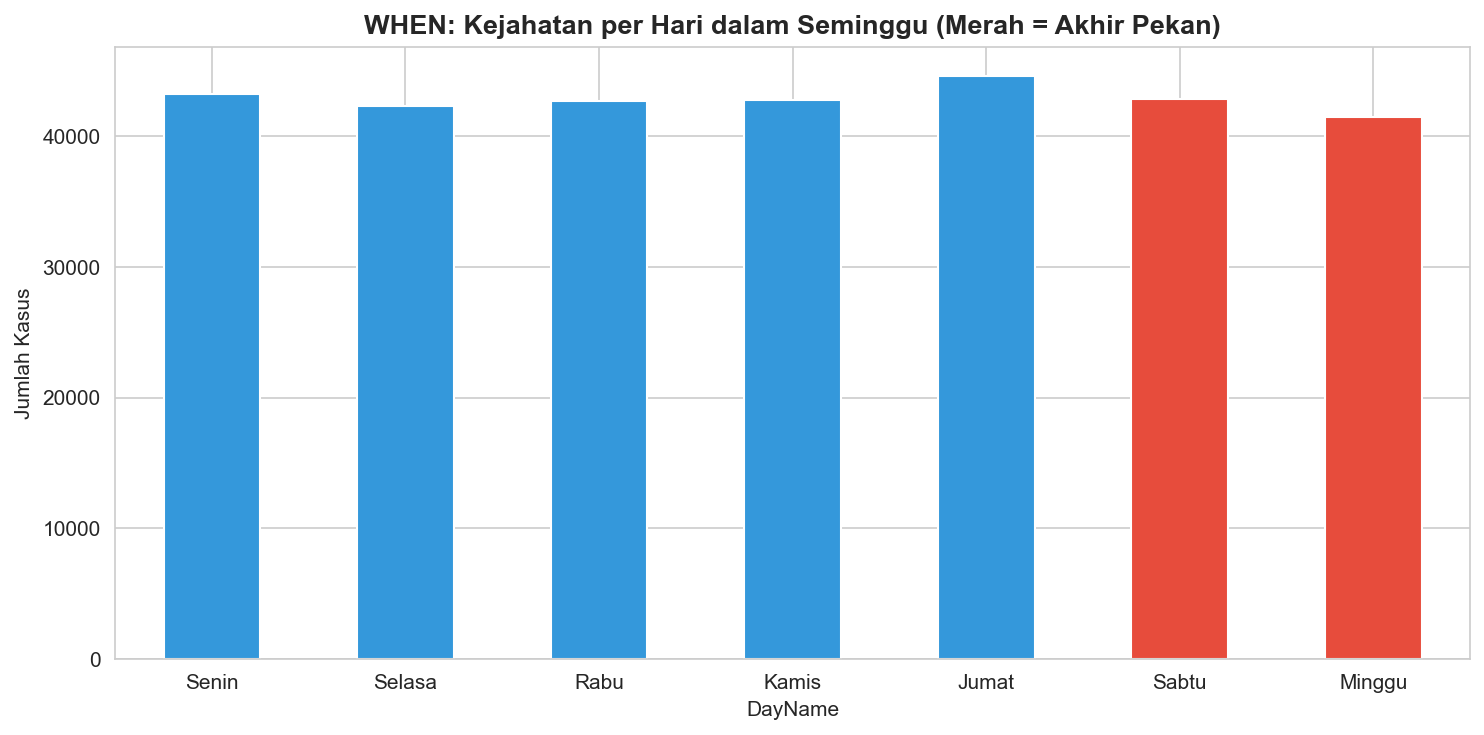

In [14]:
print("\n[3.2] Distribusi Kejahatan per Hari:")
day_map = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}
df['DayName'] = df['DayOfWeek'].map(day_map)
days_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
daily = df['DayName'].value_counts().reindex(days_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db' if d not in ['Sabtu','Minggu'] else '#e74c3c' for d in days_order]
daily.plot(kind='bar', ax=ax, color=colors)
ax.set_title('WHEN: Kejahatan per Hari dalam Seminggu (Merah = Akhir Pekan)', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Kasus')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUT}/when_02_day.png', bbox_inches='tight')
plt.show()


[3.3] Heatmap Hari vs Jam:


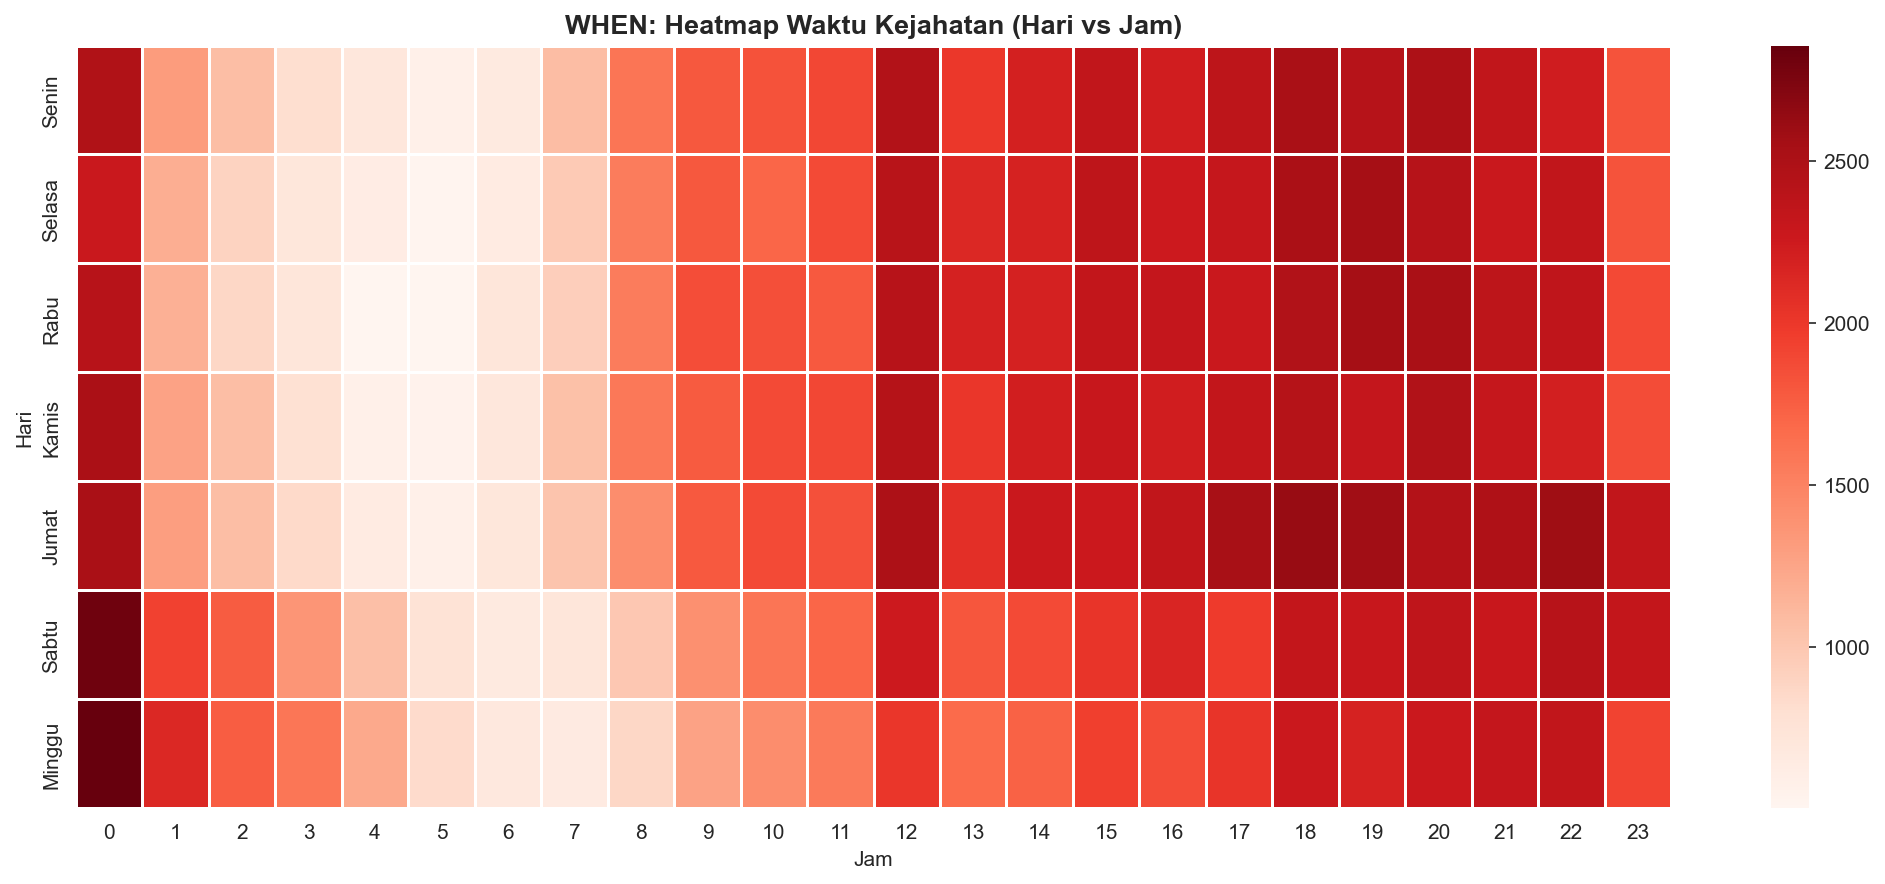

In [15]:
print("\n[3.3] Heatmap Hari vs Jam:")
ct_time = pd.crosstab(df['DayName'], df['Hour']).reindex(days_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct_time, cmap='Reds', ax=ax, linewidths=0.5)
ax.set_title('WHEN: Heatmap Waktu Kejahatan (Hari vs Jam)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam'); ax.set_ylabel('Hari')
plt.tight_layout()
plt.savefig(f'{OUT}/when_03_heatmap.png', bbox_inches='tight')
plt.show()


[3.4] Distribusi Kejahatan per Bulan & Musim:


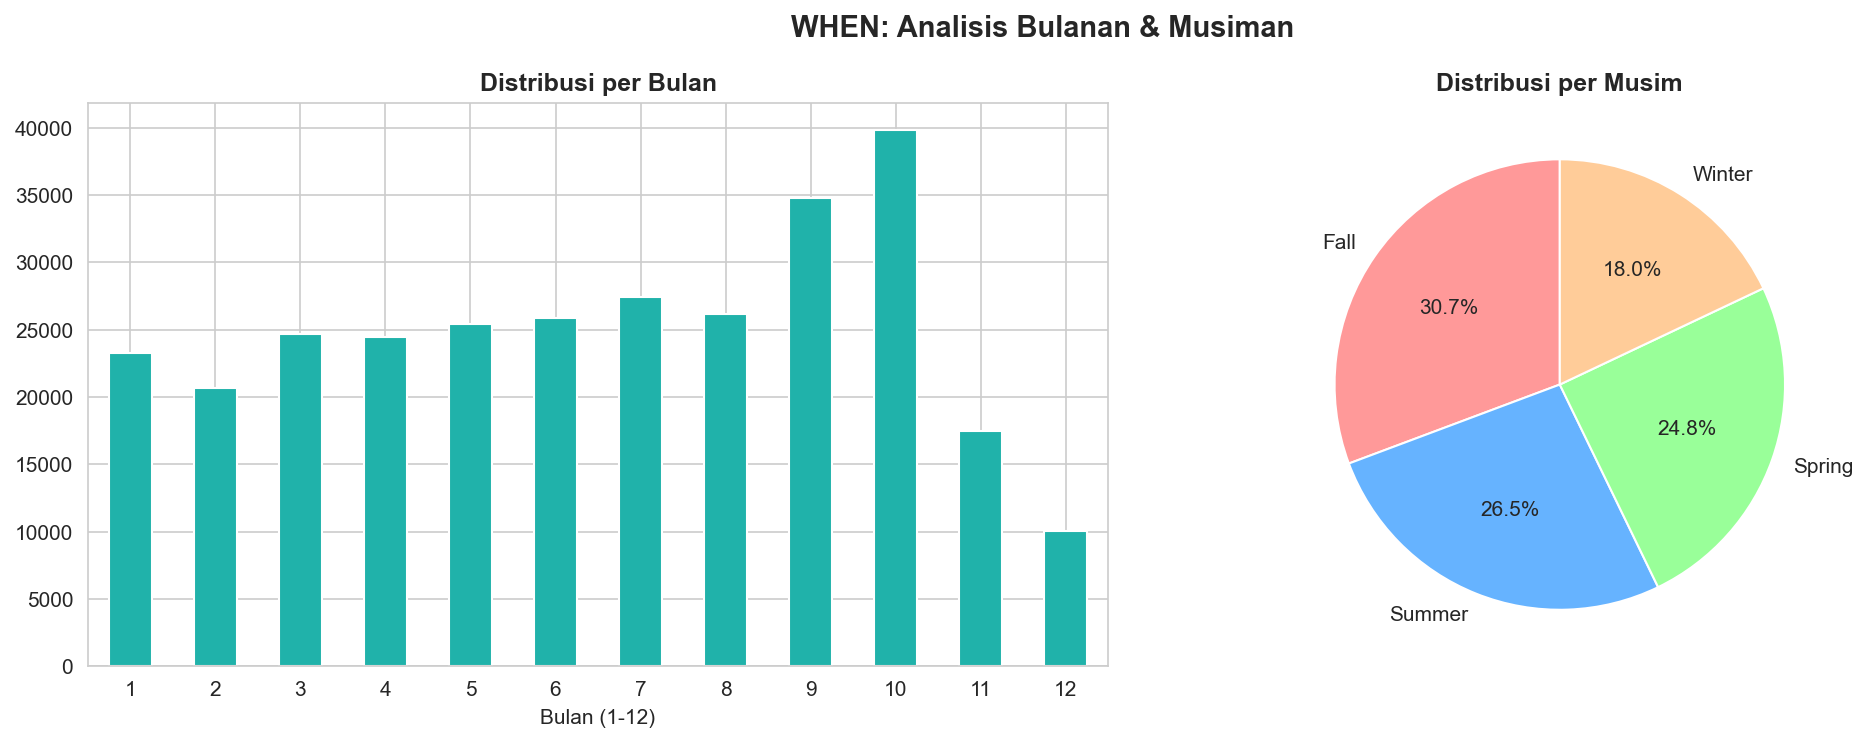

In [16]:
print("\n[3.4] Distribusi Kejahatan per Bulan & Musim:")
if 'Season' not in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Month'] = df['Date'].dt.month
    season_map = {12:'Winter',1:'Winter',2:'Winter', 3:'Spring',4:'Spring',5:'Spring', 6:'Summer',7:'Summer',8:'Summer', 9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Month'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='lightseagreen')
axes[0].set_title('Distribusi per Bulan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bulan (1-12)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

season_counts = df['Season'].value_counts()
axes[1].pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', 
            colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=90,
            wedgeprops=dict(edgecolor='w'))
axes[1].set_title('Distribusi per Musim', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('WHEN: Analisis Bulanan & Musiman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/when_04_month_season.png', bbox_inches='tight')
plt.show()


[3.5] Siang vs Malam & Weekend vs Weekday:


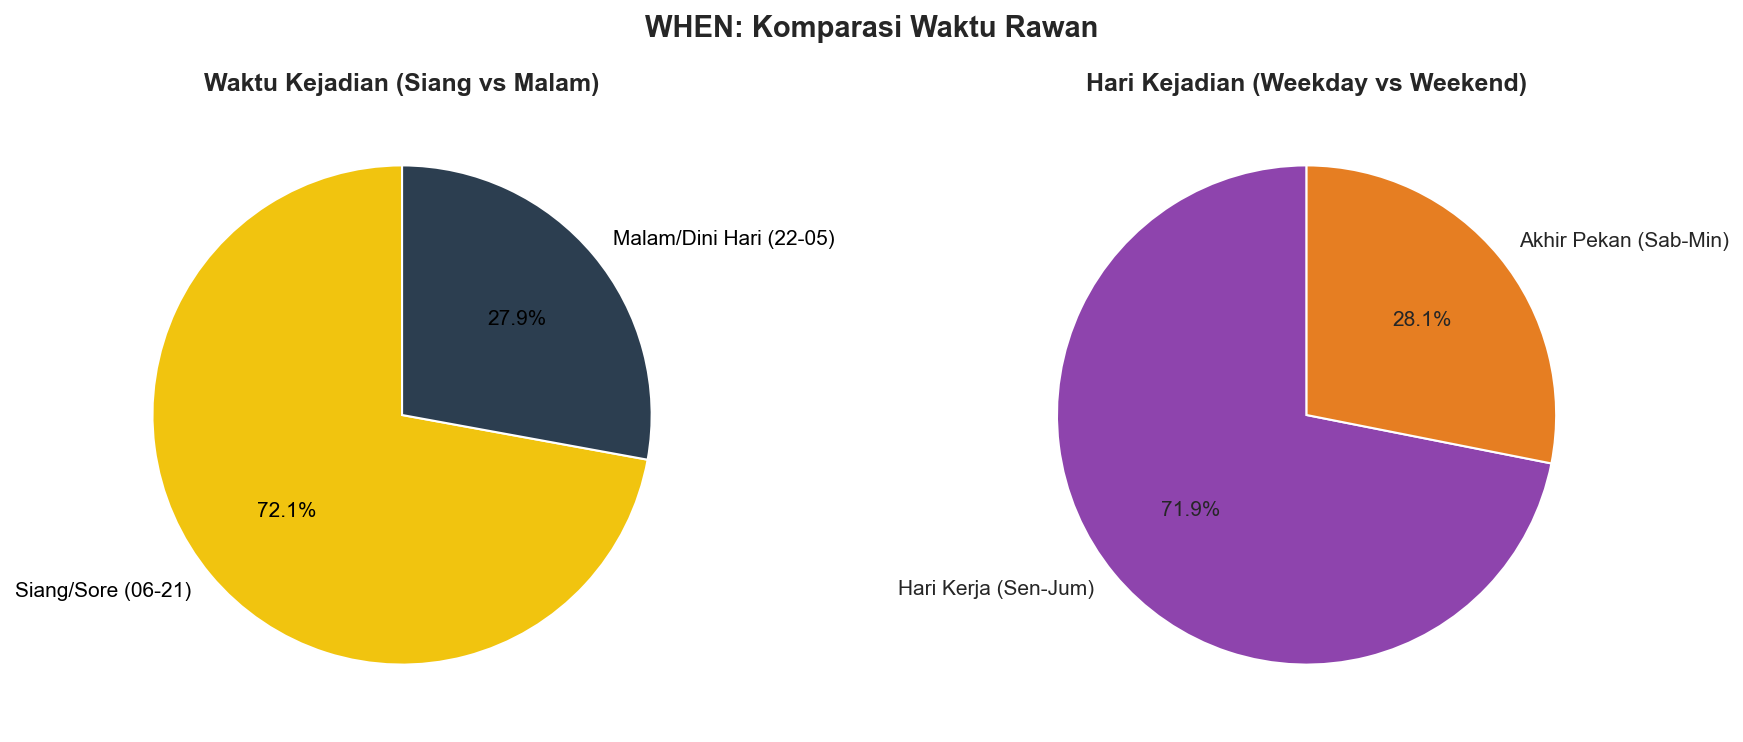

  [Saved] when_01 ~ when_05


In [17]:
print("\n[3.5] Siang vs Malam & Weekend vs Weekday:")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

daynight = df['IsNight'].value_counts().rename({0:'Siang/Sore (06-21)', 1:'Malam/Dini Hari (22-05)'})
axes[0].pie(daynight, labels=daynight.index, autopct='%1.1f%%', colors=['#f1c40f','#2c3e50'], 
            textprops={'color':"black"}, startangle=90)
axes[0].set_title('Waktu Kejadian (Siang vs Malam)', fontsize=12, fontweight='bold')

weekend = df['IsWeekend'].value_counts().rename({0:'Hari Kerja (Sen-Jum)', 1:'Akhir Pekan (Sab-Min)'})
axes[1].pie(weekend, labels=weekend.index, autopct='%1.1f%%', colors=['#8e44ad','#e67e22'], startangle=90)
axes[1].set_title('Hari Kejadian (Weekday vs Weekend)', fontsize=12, fontweight='bold')

plt.suptitle('WHEN: Komparasi Waktu Rawan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/when_05_daynight_weekend.png', bbox_inches='tight')
plt.show()
print("  [Saved] when_01 ~ when_05")